In [1]:
# ============================
# 0. 라이브러리 임포트 & 기본 설정
# ============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas_datareader import data as web

import yfinance as yf

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from arch import arch_model

from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM

from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm

from hmmlearn.hmm import GaussianHMM

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 50)

###  1.V1X와 V2X의 시계열을 추세, 계절성 및 잡음으로 분해하라

In [2]:
# ============================
# 1. 데이터 불러오기
# ============================
vix_ticker = "^VIX"
start_date = "2000-01-01"
end_date   = "2024-12-31"

vix = yf.download(vix_ticker , start=start_date , end=end_date)['Close']

# -------------------
# 1) V2X(VSTOXX) from STOXX
# -------------------
url = "https://www.stoxx.com/document/Indices/Current/HistoricalData/h_v2tx.txt"

vstoxx_raw = pd.read_csv(
    url,
    sep=";",              # ❗ 세미콜론 구분자
    decimal=".",          # 소수점 .
)

print(vstoxx_raw.head())

vstoxx_raw["Date"] = pd.to_datetime(vstoxx_raw["Date"], dayfirst=True)
vstoxx_raw.set_index("Date", inplace=True)


v2x = vstoxx_raw["Indexvalue"]

# 기간 제한
v2x = v2x.loc[start_date:end_date]

data = pd.concat([vix, v2x], axis=1)
data.columns = ['VIX', 'V2X'] 
data = data.dropna()
print(data.head())

log_data = np.log(data)
ret = log_data.diff().dropna()

print("기간: ", data.index.min().date(), "부터", data.index.max().date(), "까지")

C:\Users\User\AppData\Local\Temp\ipykernel_43360\2567096888.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix = yf.download(vix_ticker , start=start_date , end=end_date)['Close']
[*********************100%***********************]  1 of 1 completed


         Date Symbol  Indexvalue
0  04.01.1999   V2TX     18.2033
1  05.01.1999   V2TX     29.6912
2  06.01.1999   V2TX     25.1670
3  07.01.1999   V2TX     32.5205
4  08.01.1999   V2TX     33.2296
                  VIX      V2X
Date                          
2000-01-03  24.209999  30.9845
2000-01-04  27.010000  33.2225
2000-01-05  26.410000  32.5944
2000-01-06  25.730000  31.1811
2000-01-07  21.719999  27.4407
기간:  2000-01-03 부터 2024-12-30 까지


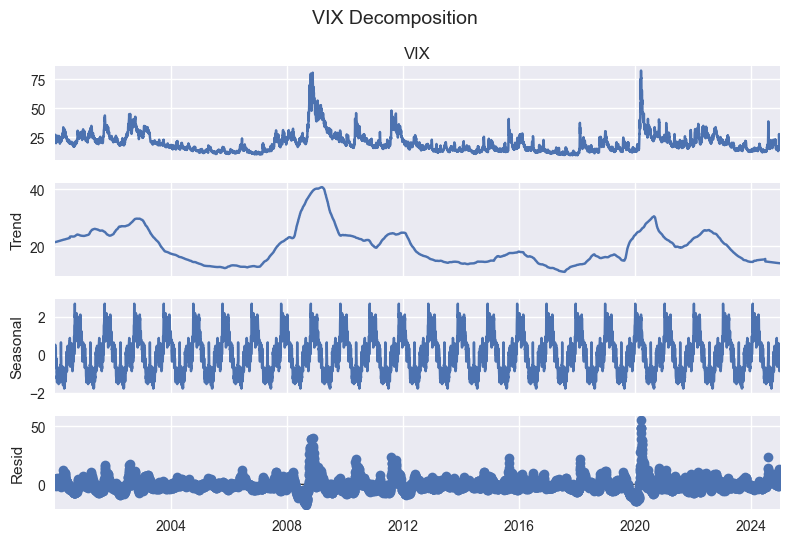

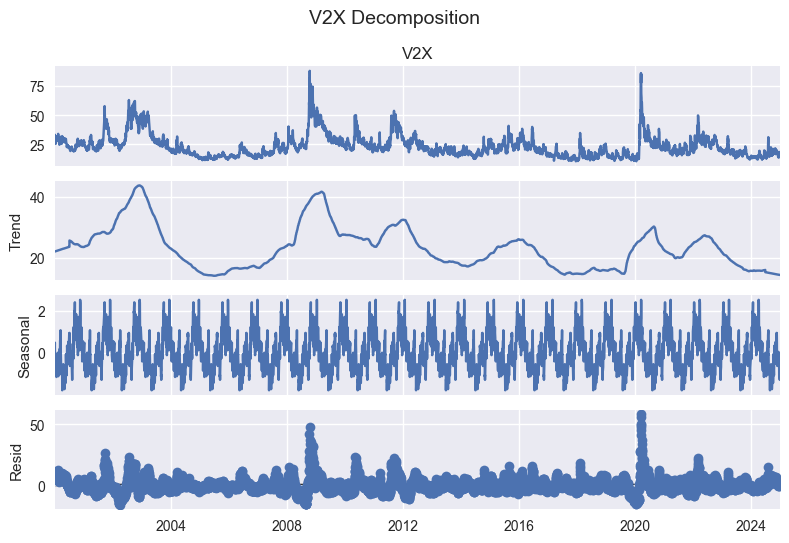

In [3]:
period = 252

decomp_vix = seasonal_decompose(data["VIX"], model="additive", period=period, extrapolate_trend='freq')
decomp_v2x = seasonal_decompose(data["V2X"], model="additive", period=period, extrapolate_trend='freq')

fig = decomp_vix.plot()
fig.suptitle("VIX Decomposition", fontsize=14)
plt.tight_layout()

fig = decomp_v2x.plot()
fig.suptitle("V2X Decomposition", fontsize=14)
plt.tight_layout()
plt.show()

### 2.VIX와 V2X 각각에 대해 단위근 테스트를 실행하고 정상성을 살펴보라

In [4]:
def adf_test(series, title=''):
    """
    Augmented Dickey-Fuller Test
    """
    print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna(), autolag='AIC')
    labels = ['ADF Test Statistic', 'p-value', '# Lags Used', '# Observations Used']
    out = pd.Series(result[0:4], index=labels)
    for key, value in result[4].items():
        out[f'Critical Value ({key})'] = value
    print(out.to_string())
    if result[1] <= 0.05:
        print("=> The series is stationary.")
    else:
        print("=> it is non-stationary.")
    print('\n')

adf_test(data["VIX"], title="VIX")
adf_test(data["V2X"], title="V2X")
adf_test(ret["VIX"], title="VIX Returns")
adf_test(ret["V2X"], title="V2X Returns")

Augmented Dickey-Fuller Test: VIX
ADF Test Statistic     -5.836626e+00
p-value                 3.862967e-07
# Lags Used             1.300000e+01
# Observations Used     6.186000e+03
Critical Value (1%)    -3.431408e+00
Critical Value (5%)    -2.862007e+00
Critical Value (10%)   -2.567019e+00
=> The series is stationary.


Augmented Dickey-Fuller Test: V2X
ADF Test Statistic        -5.569389
p-value                    0.000001
# Lags Used               19.000000
# Observations Used     6180.000000
Critical Value (1%)       -3.431409
Critical Value (5%)       -2.862008
Critical Value (10%)      -2.567019
=> The series is stationary.


Augmented Dickey-Fuller Test: VIX Returns
ADF Test Statistic       -31.308147
p-value                    0.000000
# Lags Used                8.000000
# Observations Used     6190.000000
Critical Value (1%)       -3.431407
Critical Value (5%)       -2.862007
Critical Value (10%)      -2.567019
=> The series is stationary.


Augmented Dickey-Fuller Test: V2X 

- vix와 v2x 는 level 에서도 정상성을 만족 
- 하지만 vix의 경우, 에러 자기 상관을 제거하기 위해 27의 lag를 추가해야 하기 때문에
- 두 지수 모두 로그 수익률로 분석하는 것이 적합해 보임 

### 3.VIX와 V2X 각각에 대해 ARIMA GARCH 모델을 적용하라.

In [5]:
# VIX ARIMA 모델 적합
vix_log = log_data['VIX'].dropna()
vix_arima_model = ARIMA(vix_log, order=(1,1,1))
vix_arima_result = vix_arima_model.fit()
print(vix_arima_result.summary()) 
# ARMIMA(1,1,1) 적합 결과, 계수 모두 유의
# p= 0.93으로 자기 상관은 존재 하지 않으나 prob(jb)=0으로 변동성이 시간에 따라 달라짐을 확인  
# 잔차가 정규분포가 아니기 때문에 GARCH 모델링 필요 

# VIX ARIMA 잔차로 GARCH(1,1) 모델 적합 
vix_resid = vix_arima_result.resid.dropna()
vix_resid_scaled = vix_resid * 100  # GARCH 모델 warning 해소 위해 스케일링 적용 
vix_garch = arch_model(vix_resid_scaled, vol="GARCH", p=1, q=1, dist="t")
vix_garch_res = vix_garch.fit(disp="off") #경고 무시 
print(vix_garch_res.summary())
# GARCH(1,1) 모델 적합 결과, 알파 베타의 합은 0.88로 충격이 오래 남아있으나 안정적인 것 확인 

# V2X ARIMA 모델 적합
v2x_log = log_data["V2X"].dropna()
v2x_arima_model = ARIMA(v2x_log, order=(1,1,1))
v2x_arima_res = v2x_arima_model.fit()
print(v2x_arima_res.summary())
# ar1이 0.8994로 높게 나와 충격이 오래 남아있음을 의미 
# 유럽 변동성 지수가 미국보다 조금 더 느리고 점진적으로 움직이는 경향 
# ma1 은 음수로 나와서 반대 방향으로 움직이는 경향을 보임 
# prob 0.79로 잔차에 자기 상관은 존재 하지 않지만, prob(jb)=0으로 변동성이 시간에 따라 달라짐
# 잔차가 정규분포가 아니기 때문에 GARCH 모델링 필요 


# V2X ARIMA 잔차로 GARCH(1,1) 모델 적합
v2x_resid = v2x_arima_res.resid.dropna()
v2x_resid_scaled = v2x_resid * 100  
v2x_garch = arch_model(v2x_resid_scaled, vol="GARCH", p=1, q=1, dist="t")
v2x_garch_res = v2x_garch.fit(disp="off")
print(v2x_garch_res.summary())
# 알파 베타의 합이 0.84로 매우 높은 변동성의 지속성을 보인다 

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                    VIX   No. Observations:                 6200
Model:                 ARIMA(1, 1, 1)   Log Likelihood                7623.528
Date:                Sat, 22 Nov 2025   AIC                         -15241.057
Time:                        23:18:36   BIC                         -15220.860
Sample:                             0   HQIC                        -15234.055
                               - 6200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7971      0.020     40.107      0.000       0.758       0.836
ma.L1         -0.8832      0.015    -57.231      0.000      -0.913      -0.853
sigma2         0.0050   4.26e-05    117.557      0.0

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                    V2X   No. Observations:                 6200
Model:                 ARIMA(1, 1, 1)   Log Likelihood                8261.880
Date:                Sat, 22 Nov 2025   AIC                         -16517.760
Time:                        23:18:36   BIC                         -16497.564
Sample:                             0   HQIC                        -16510.758
                               - 6200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9466      0.006    161.345      0.000       0.935       0.958
ma.L1         -0.9834      0.004   -256.395      0.000      -0.991      -0.976
sigma2         0.0041   4.23e-05     96.285      0.0

### 4.VIX와 V2X에 대해 Multivariate GARCH 모델을 적용해보라.

In [6]:
import mgarch

# 1) 잔차 정렬 
aligned_resid = pd.concat([vix_resid_scaled, v2x_resid_scaled], axis=1).dropna()
aligned_resid.columns = ['VIX_Resid', 'V2X_Resid']

#  mgarch 입력 형식 맞추기 
rt = aligned_resid.to_numpy()   

# DCC-GARCH 적합 
vol = mgarch.mgarch()   
vol.fit(rt)

# 1-step ahead 조건부 공분산 예측
pred_1 = vol.predict(1)
H = pred_1['cov']  #공분산 행렬만 따로 가져오기 

# 변동성, 상관계수, hedge ratio 계산
sigma_vix_scaled = np.sqrt(H[0, 0])
sigma_v2x_scaled = np.sqrt(H[1, 1])

rho = H[0, 1] / (sigma_vix_scaled * sigma_v2x_scaled)   # 상관계수
beta = H[0, 1] / H[1, 1]                                # hedge ratio

print("=== Scaled version ===")
print("σ_VIX (scaled):", sigma_vix_scaled)
print("σ_V2X (scaled):", sigma_v2x_scaled)
print("corr(VIX, V2X):", rho)
print("hedge ratio β (VIX / V2X):", beta)
## corr = -0.006으로 오늘 vix가 튀었다고 , 오늘 v2x가 같이 튀는 형태는 아니라는 의미 

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\mgarch\mgarch.py:65: RuntimeWarning: invalid value encountered in log
  np.log(np.linalg.det(R_t[i])) + \
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\mgarch\mgarch.py:56: RuntimeWarning: invalid value encountered in sqrt
  qts = np.linalg.inv(np.sqrt(np.diag(np.diag(Q_t[i]))))
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\linalg\_linalg.py:2430: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


=== Scaled version ===
σ_VIX (scaled): 12.378976796585182
σ_V2X (scaled): 5.917282017278915
corr(VIX, V2X): -0.015277021792870382
hedge ratio β (VIX / V2X): -0.03195958849732725


### 5. V1X와 V2X를 이용해 VAR 모델을 만들고, Granger causality 테스트를 실행하고, Impulse response 그래프와 분산 분해(Varinace Decomposion)을 계산하고 그래프 로 보여라.

In [7]:
# VAR는 보통 수익률 사용
var_data = ret.dropna()

# 최적 차수 선택
model_var = VAR(var_data)
lag_order_results = model_var.select_order(maxlags=10)
print(lag_order_results.summary())

selected_lag = lag_order_results.aic  
p = selected_lag
print("VAR 차수:", p)

var_res = model_var.fit(p)
print(var_res.summary())

# 두 시계열이 10일 전까지 영향을 주고 받으면서, v2x가 1 오르면 , vix가 0.6 오름 

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -11.12      -11.12   1.480e-05      -11.12
1       -11.29      -11.28   1.251e-05      -11.29
2       -11.32      -11.31   1.214e-05      -11.32
3       -11.33      -11.32   1.196e-05      -11.33
4       -11.34     -11.32*   1.186e-05      -11.34
5       -11.35      -11.32   1.183e-05      -11.34
6       -11.35      -11.32   1.180e-05      -11.34
7       -11.35      -11.32   1.179e-05      -11.34
8       -11.35      -11.32   1.175e-05      -11.34
9      -11.35*      -11.31  1.172e-05*     -11.34*
10      -11.35      -11.31   1.172e-05      -11.34
--------------------------------------------------
VAR 차수: 9
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 22, Nov, 2025
Time:                     23:18:52
--------------------------------------------------

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [8]:
# ----- Granger causality -----
# VIX -> V2X / V2X -> VIX 둘 다 확인
print("\nGranger causality test: VIX to V2X?")
print(var_res.test_causality("V2X", ["VIX"], kind="f")) 
#p_value 0.00 으로 VIX가 V2X에 유의미한 영향

print("\nGranger causality test: V2X to VIX?")
print(var_res.test_causality("VIX", ["V2X"], kind="f"))
#유의마한 영향은 없음 (미국장이 먼저 앞서고 , 유럽장이 따라가는 구조임을 의미)



Granger causality test: VIX to V2X?
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: VIX does not Granger-cause V2X: reject at 5% significance level. Test statistic: 74.361, critical value: 1.881>, p-value: 0.000>

Granger causality test: V2X to VIX?
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: V2X does not Granger-cause VIX: reject at 5% significance level. Test statistic: 2.079, critical value: 1.881>, p-value: 0.028>


Text(0.5, 0.98, 'Variance Decomposition (VAR)')

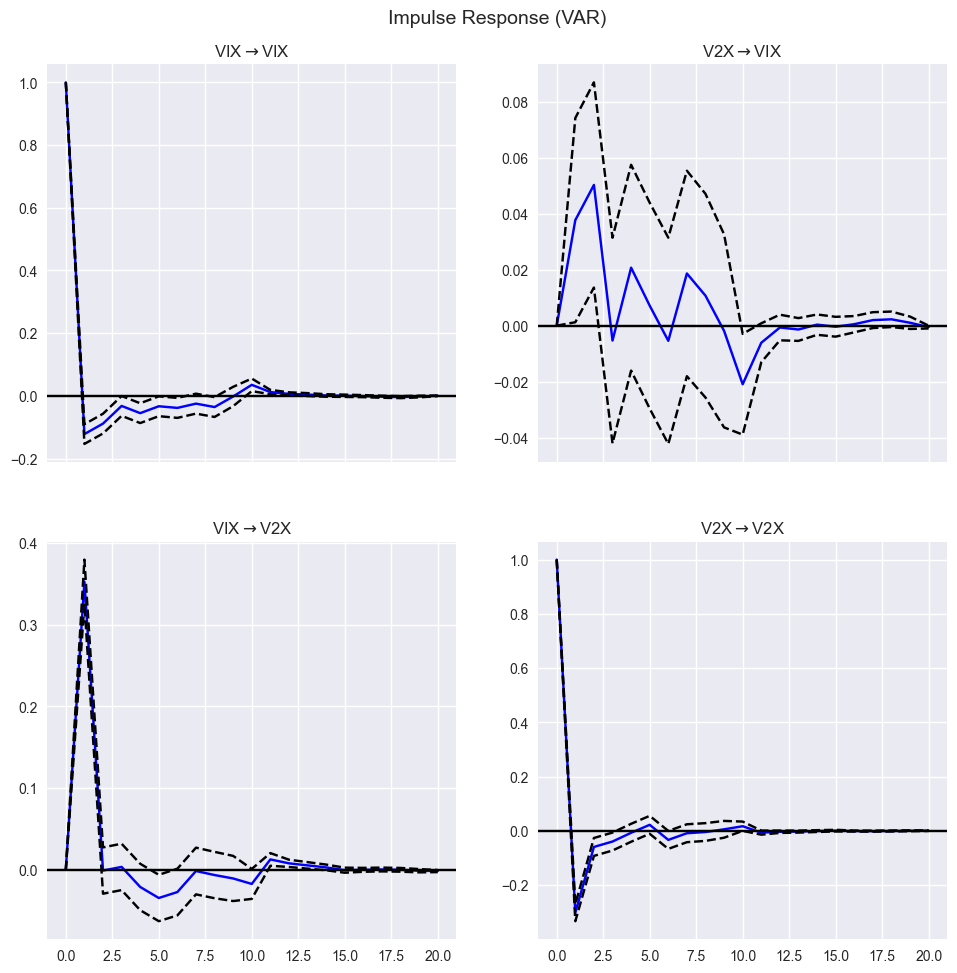

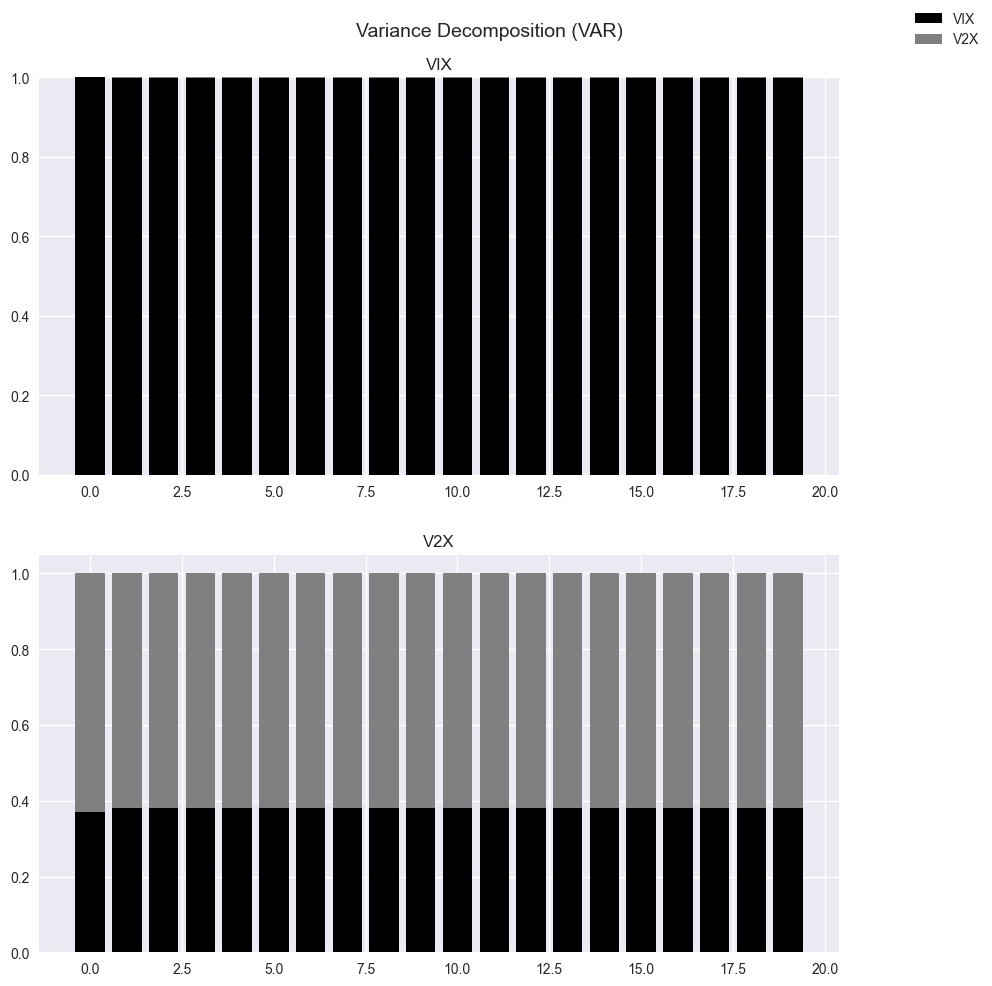

In [9]:
# ----- Impulse Response Function -----
irf = var_res.irf(20)  # 20일
fig = irf.plot(orth=False)
plt.suptitle("Impulse Response (VAR)", fontsize=14)

# ----- Variance Decomposition (FEVD) -----
fevd = var_res.fevd(20)
fig = fevd.plot()
plt.suptitle("Variance Decomposition (VAR)", fontsize=14)

# vix는 단기적으로도 (하루 이틀) v2x에 영향 미치기도 하고 장기적으로도 40% 정도 영향을 줌 

In [10]:
# ============================
# 7. 공적분 관계 + VECM
# ============================

# 가격 수준 사용
price_for_coint = data[["VIX", "V2X"]].dropna()

# Johansen 공적분 테스트
# det_order=-1 => 자동, k_ar_diff=1 => 1차 차분 포함
jres = coint_johansen(price_for_coint, det_order=0, k_ar_diff=1)
print("\nJohansen test eigenvalues:", jres.eig)
print("Trace statistics:", jres.lr1)
print("Critical values (90/95/99):")
print(jres.cvt)

# 공적분 벡터(첫 번째)를 사용
coint_vec = jres.evec[:, 0]
print("추정 공적분 벡터:", coint_vec)

# VECM 적합
vecm_model = VECM(price_for_coint, k_ar_diff=1, coint_rank=1, deterministic="ci")
vecm_res = vecm_model.fit()
print(vecm_res.summary())

# VIX=0.9047⋅V2X−2.01 의 형태로 공적분 관계를 형성한다 
# v2x 알파는 유의미하게 음수로 나와서 V2X가 VIX의 움직임을 따라가려고 하는 패턴 (미국은 알아서)
# L1.VIX on V2X = 0.3684 (p < 0.000) 로 단기적으로 vix 충격이 v2x를 움직임을 확인 


Johansen test eigenvalues: [0.02109435 0.00789622]
Trace statistics: [181.27649645  49.13502838]
Critical values (90/95/99):
[[13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]
추정 공적분 벡터: [ 0.27375434 -0.24490764]


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Det. terms outside the coint. relation & lagged endog. parameters for equation VIX
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.VIX        -0.1278      0.016     -8.196      0.000      -0.158      -0.097
L1.V2X        -0.0218      0.015     -1.415      0.157      -0.052       0.008
Det. terms outside the coint. relation & lagged endog. parameters for equation V2X
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.VIX         0.3240      0.015     21.613      0.000       0.295       0.353
L1.V2X        -0.2133      0.015    -14.410      0.000      -0.242      -0.184
                Loading coefficients (alpha) for equation VIX                 
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------

- VIX–V2X는 장기적으로 공적분 관계(0.9 비율)로 묶여 있으며,
- 단기 충격은 미국→유럽 방향으로 전달되고,
- 장기 조정도 유럽이 담당한다.
- 즉, 미국 변동성이 유럽 변동성을 주도한다.


OLS hedge ratio: beta0 = 0.9966172206841248 , beta1 = 0.8116414811356469


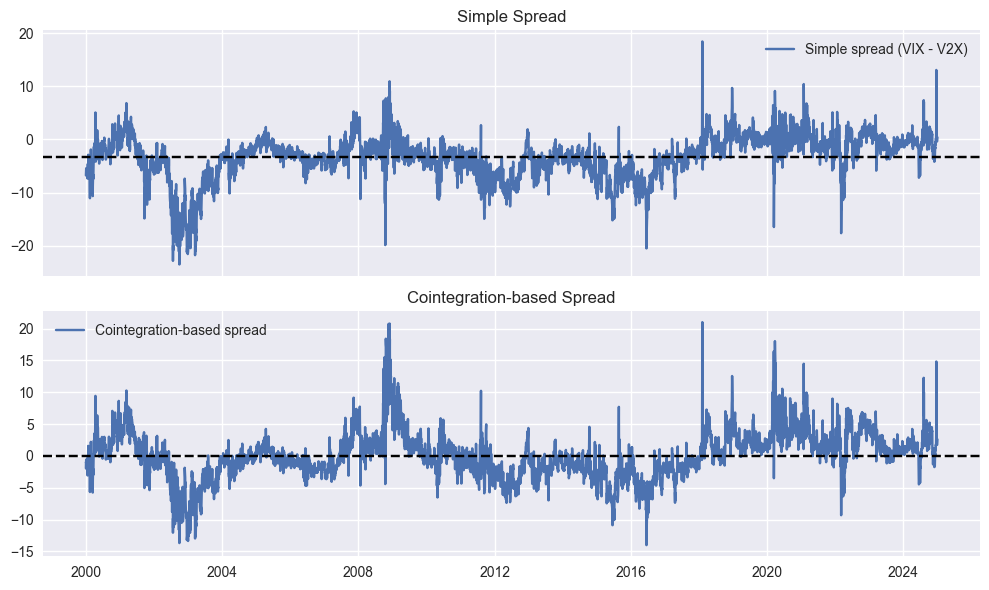

In [11]:
# ============================
# 8. 페어트레이딩 준비: 스프레드 구성
# ============================

# (1) 단순 스프레드: VIX - V2X
spread_simple = data["VIX"] - data["V2X"]

# (2) 공적분 기반 스프레드 (OLS로 hedge ratio 추정)
y = data["VIX"]
x = sm.add_constant(data["V2X"])
ols_res = OLS(y, x).fit()
beta0, beta1 = ols_res.params
print("\nOLS hedge ratio: beta0 =", beta0, ", beta1 =", beta1)

spread_coint = y - (beta0 + beta1 * data["V2X"])

# 스프레드 시각화
fig, axes = plt.subplots(2, 1, figsize=(10,6), sharex=True)
axes[0].plot(spread_simple, label="Simple spread (VIX - V2X)")
axes[0].axhline(spread_simple.mean(), color="black", linestyle="--")
axes[0].set_title("Simple Spread")
axes[0].legend()

axes[1].plot(spread_coint, label="Cointegration-based spread")
axes[1].axhline(spread_coint.mean(), color="black", linestyle="--")
axes[1].set_title("Cointegration-based Spread")
axes[1].legend()
plt.tight_layout()

# 공적분 기반 스프레드는 헷지비율 조정 덕분에 더 안정적이고 평균회귀성이 더 뚜렷함 

In [12]:
def hurst_exponent(series):
    s = pd.Series(series).dropna().values   
    N = len(s)
    if N < 100:
        return np.nan

    lags = range(2, 20)
    tau = []
    for lag in lags:
        diff = s[lag:] - s[:-lag]          
        tau.append(np.sqrt(np.std(diff)))

    tau = np.array(tau)
    valid = tau > 0
    if valid.sum() < 3:
        return np.nan

    lags = np.array(list(lags))[valid]
    tau = tau[valid]
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    return poly[0] * 2.0



def half_life(spread):
    """
    Δspread_t = α + β * spread_{t-1} + ε
    phi = 1 + β
    half-life = -ln(2) / ln(phi)
    """
    spread = pd.Series(spread).dropna()
    lagged = spread.shift(1).dropna()
    delta = spread.diff().dropna()

    delta = delta.loc[lagged.index]

    beta = np.polyfit(lagged, delta, 1)[0]
    phi = 1 + beta

    if phi <= 0 or phi >= 1:
        # phi>=1 : mean-reversion 없음 or 발산
        # phi<=0 : 진동하는 비정상적인 케이스
        return np.inf

    hl = -np.log(2) / np.log(phi)
    return hl


# ---------------------------
# 3. 최종 성과 요약 함수
# ---------------------------
def summarize_pnl_full(pnl_series, spread_series, name="", trading_days=252):
    pnl = pnl_series.dropna()
    equity = (1 + pnl).cumprod()

    total_ret = equity.iloc[-1] - 1
    ann_ret = (1 + total_ret)**(trading_days/len(equity)) - 1
    ann_vol = pnl.std() * np.sqrt(trading_days)
    sharpe = ann_ret / ann_vol if ann_vol != 0 else np.nan

    cummax = equity.cummax()
    dd = (equity - cummax) / cummax
    maxdd = dd.min()

    # 허스트 / 반감기는 스프레드 기준으로!
    H = hurst_exponent(spread_series)
    HL = half_life(spread_series)

    print(f"\n=== {name} Performance (Full) ===")
    print("Annualized Return  :", ann_ret)
    print("Annualized Vol     :", ann_vol)
    print("Sharpe Ratio       :", sharpe)
    print("Max Drawdown       :", maxdd)
    print("Hurst Exponent     :", H)
    print("Half-life (days)   :", HL)

    return {
        "Strategy": name,
        "AnnReturn": ann_ret,
        "AnnVol": ann_vol,
        "Sharpe": sharpe,
        "MaxDD": maxdd,
        "Hurst": H,
        "HalfLife": HL
    }


=== Simple spread (k=1) Performance (Full) ===
Annualized Return  : -1.0
Annualized Vol     : 21.23472103209731
Sharpe Ratio       : -0.047092683651857335
Max Drawdown       : -29.28331669295313
Hurst Exponent     : 0.1850086830212694
Half-life (days)   : 7.766269290542532


{'Strategy': 'Simple spread (k=1)',
 'AnnReturn': np.float64(-1.0),
 'AnnVol': np.float64(21.23472103209731),
 'Sharpe': np.float64(-0.047092683651857335),
 'MaxDD': np.float64(-29.28331669295313),
 'Hurst': np.float64(0.1850086830212694),
 'HalfLife': np.float64(7.766269290542532)}

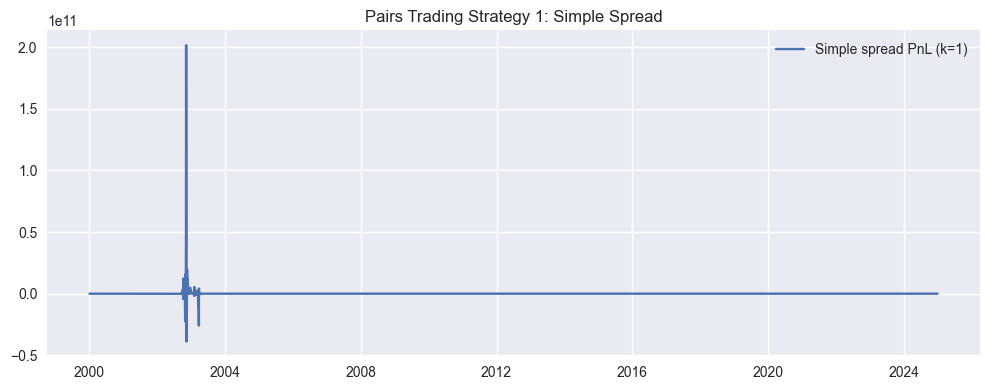

In [13]:
# ============================
# 9. 페어트레이딩 1: 단순 스프레드 (mean ± kσ)
# ============================

k = 1.0  # 진입 경계 계수
mu_s = spread_simple.mean()
sigma_s = spread_simple.std()

upper_s = mu_s + k * sigma_s
lower_s = mu_s - k * sigma_s

position_simple = pd.Series(0, index=spread_simple.index)  # +1: long VIX/short V2X, -1: 반대

for t in range(1, len(spread_simple)):
    prev_pos = position_simple.iloc[t-1]
    s = spread_simple.iloc[t]

    if prev_pos == 0:
        if s > upper_s:
            # 스프레드가 너무 커졌음: VIX 고평가, V2X 저평가 → VIX short, V2X long → 포지션 -1
            position_simple.iloc[t] = -1
        elif s < lower_s:
            # 스프레드가 너무 작아졌음: VIX 저평가, V2X 고평가 → VIX long, V2X short → 포지션 +1
            position_simple.iloc[t] = 1
        else:
            position_simple.iloc[t] = 0
    else:
        # mean으로 회귀하면 청산
        if (prev_pos == 1 and s >= mu_s) or (prev_pos == -1 and s <= mu_s):
            position_simple.iloc[t] = 0
        else:
            position_simple.iloc[t] = prev_pos

# 포트폴리오 수익률 (스프레드에 반대 방향으로 베팅)
spread_ret = spread_simple.diff().fillna(0)
pnl_simple = -position_simple.shift(1).fillna(0) * spread_ret
cum_pnl_simple = (1 + pnl_simple).cumprod()

plt.figure(figsize=(10,4))
plt.plot(cum_pnl_simple, label="Simple spread PnL (k=1)")
plt.title("Pairs Trading Strategy 1: Simple Spread")
plt.legend()
plt.tight_layout()

# 성과 요약
perf_simple  = summarize_pnl_full(pnl_simple, spread_simple, "Simple spread (k=1)")
perf_simple


=== Cointegration spread Performance (Full) ===
Annualized Return  : -1.0
Annualized Vol     : 20.651714658973265
Sharpe Ratio       : -0.04842212942185386
Max Drawdown       : -2.342306193860264
Hurst Exponent     : 0.1788934381873446
Half-life (days)   : 7.356820234749396


{'Strategy': 'Cointegration spread',
 'AnnReturn': np.float64(-1.0),
 'AnnVol': np.float64(20.651714658973265),
 'Sharpe': np.float64(-0.04842212942185386),
 'MaxDD': np.float64(-2.342306193860264),
 'Hurst': np.float64(0.1788934381873446),
 'HalfLife': np.float64(7.356820234749396)}

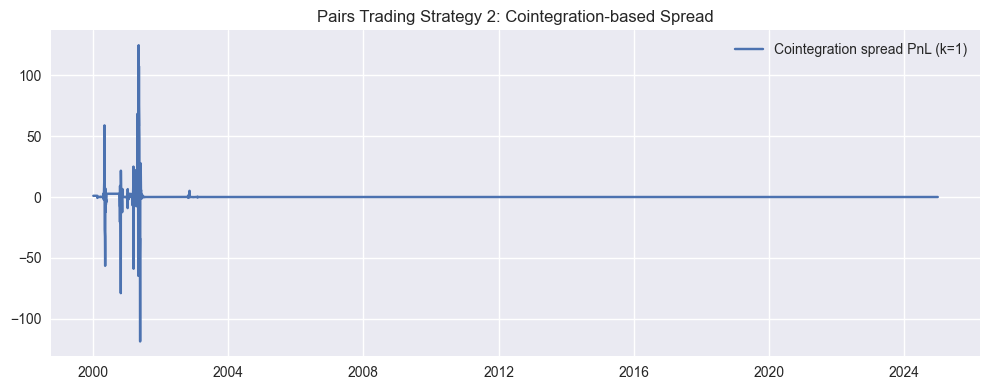

In [14]:
# ============================
# 10. 페어트레이딩 2: 공적분 스프레드 사용
# ============================

k_c = 1.0
mu_c = spread_coint.mean()
sigma_c = spread_coint.std()
upper_c = mu_c + k_c * sigma_c
lower_c = mu_c - k_c * sigma_c

position_coint = pd.Series(0, index=spread_coint.index)

for t in range(1, len(spread_coint)):
    prev_pos = position_coint.iloc[t-1]
    s = spread_coint.iloc[t]

    if prev_pos == 0:
        if s > upper_c:
            position_coint.iloc[t] = -1  # 스프레드 크다 → hedge ratio대로 short-long 포지션
        elif s < lower_c:
            position_coint.iloc[t] = 1
        else:
            position_coint.iloc[t] = 0
    else:
        if (prev_pos == 1 and s >= mu_c) or (prev_pos == -1 and s <= mu_c):
            position_coint.iloc[t] = 0
        else:
            position_coint.iloc[t] = prev_pos

spread_c_ret = spread_coint.diff().fillna(0)
pnl_coint = -position_coint.shift(1).fillna(0) * spread_c_ret
cum_pnl_coint = (1 + pnl_coint).cumprod()

plt.figure(figsize=(10,4))
plt.plot(cum_pnl_coint, label="Cointegration spread PnL (k=1)")
plt.title("Pairs Trading Strategy 2: Cointegration-based Spread")
plt.legend()
plt.tight_layout()

perf_coint  = summarize_pnl_full(pnl_coint,  spread_coint,  "Cointegration spread")
perf_coint


=== Kalman spread Performance (Full) ===
Annualized Return  : -1.0
Annualized Vol     : 14.691686714051295
Sharpe Ratio       : -0.06806570405858088
Max Drawdown       : -2.9153147235744337
Hurst Exponent     : 0.029697392263013406
Half-life (days)   : 0.5916258869700407


{'Strategy': 'Kalman spread',
 'AnnReturn': np.float64(-1.0),
 'AnnVol': np.float64(14.691686714051295),
 'Sharpe': np.float64(-0.06806570405858088),
 'MaxDD': np.float64(-2.9153147235744337),
 'Hurst': np.float64(0.029697392263013406),
 'HalfLife': np.float64(0.5916258869700407)}

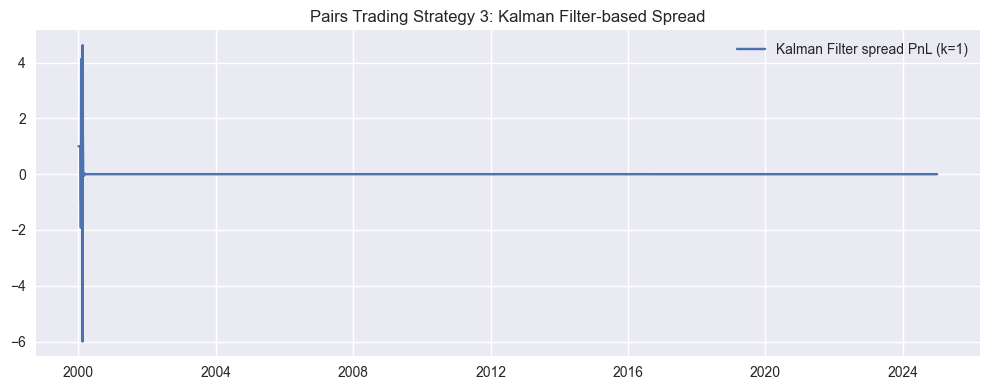

In [15]:
# ============================
# 11. 페어트레이딩 3: 칼만 필터 기반 동적 헷지비율 (간단 버전)
# ============================
# 여기서는 '시간에 따라 변하는 beta'를 매우 단순한 Kalman Filter 형태로 구현
# (정교한 버전은 pykalman 등 라이브러리 쓰는 걸 추천)

# 상태: [beta0, beta1]
n = len(data)
beta0_kf = np.zeros(n)
beta1_kf = np.zeros(n)

# 초기값
beta0_kf[0] = beta0
beta1_kf[0] = beta1

# 공분산 행렬 초기값
P = np.eye(2) * 1.0
Q = np.eye(2) * 0.0001   # 상태 잡음 (작게)
R = 1.0                  # 관측 잡음

v2 = data["V2X"].values
vix_arr = data["VIX"].values

for t in range(1, n):
    # 예측 단계 (random walk 가정)
    beta_pred = np.array([beta0_kf[t-1], beta1_kf[t-1]])
    P_pred = P + Q

    # y_t = beta0 + beta1 * x_t + noise
    x_t = np.array([1.0, v2[t]])
    y_t = vix_arr[t]

    # Kalman Gain
    S = x_t @ P_pred @ x_t.T + R
    K = (P_pred @ x_t.T) / S

    # 업데이트
    y_hat = x_t @ beta_pred
    beta_update = beta_pred + K * (y_t - y_hat)
    P = P_pred - np.outer(K, x_t) @ P_pred

    beta0_kf[t] = beta_update[0]
    beta1_kf[t] = beta_update[1]

# 동적 스프레드
spread_kf = data["VIX"] - (beta0_kf + beta1_kf * data["V2X"].values)

k_kf = 1.0
mu_kf = spread_kf.mean()
sigma_kf = spread_kf.std()
upper_kf = mu_kf + k_kf * sigma_kf
lower_kf = mu_kf - k_kf * sigma_kf

position_kf = pd.Series(0, index=data.index)

for t in range(1, len(data)):
    prev_pos = position_kf.iloc[t-1]
    s = spread_kf.iloc[t]

    if prev_pos == 0:
        if s > upper_kf:
            position_kf.iloc[t] = -1
        elif s < lower_kf:
            position_kf.iloc[t] = 1
        else:
            position_kf.iloc[t] = 0
    else:
        if (prev_pos == 1 and s >= mu_kf) or (prev_pos == -1 and s <= mu_kf):
            position_kf.iloc[t] = 0
        else:
            position_kf.iloc[t] = prev_pos

spread_kf_ret = spread_kf.diff().fillna(0)
pnl_kf = -position_kf.shift(1).fillna(0) * spread_kf_ret
cum_pnl_kf = (1 + pnl_kf).cumprod()

plt.figure(figsize=(10,4))
plt.plot(cum_pnl_kf, label="Kalman Filter spread PnL (k=1)")
plt.title("Pairs Trading Strategy 3: Kalman Filter-based Spread")
plt.legend()
plt.tight_layout()

perf_kf  = summarize_pnl_full(pnl_kf,     spread_kf,     "Kalman spread")
perf_kf


HMM state means: [0.0007658  0.00058416]
Mean-reverting state index: 1

=== HMM + Cointegration spread Performance (Full) ===
Annualized Return  : nan
Annualized Vol     : 17.399222097553512
Sharpe Ratio       : nan
Max Drawdown       : -450.5127865455904
Hurst Exponent     : 0.1788934381873446
Half-life (days)   : 7.356820234749396


C:\Users\User\AppData\Local\Temp\ipykernel_43360\314949440.py:57: RuntimeWarning: invalid value encountered in scalar power
  ann_ret = (1 + total_ret)**(trading_days/len(equity)) - 1


{'Strategy': 'HMM + Cointegration spread',
 'AnnReturn': np.float64(nan),
 'AnnVol': np.float64(17.399222097553512),
 'Sharpe': np.float64(nan),
 'MaxDD': np.float64(-450.5127865455904),
 'Hurst': np.float64(0.1788934381873446),
 'HalfLife': np.float64(7.356820234749396)}

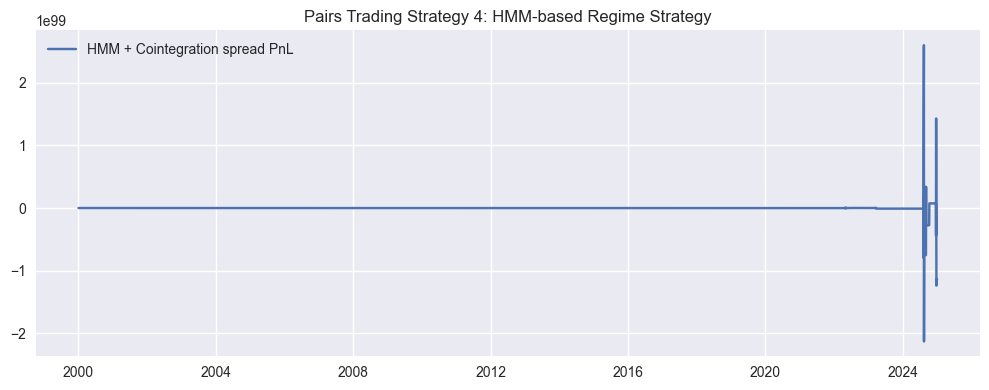

In [16]:
# ============================
# 12. 페어트레이딩 4: HMM 기반 (레짐 전환 활용)
# ============================

# 여기서는 공적분 스프레드의 수익률에 대해 2-state Gaussian HMM을 맞추고
# "평균회귀 강한 상태" 에서만 트레이딩 하는 간단 버전 예시

spread_c_diff = spread_coint.diff().dropna().values.reshape(-1, 1)

n_states = 2
hmm = GaussianHMM(n_components=n_states, covariance_type="full", n_iter=100)
hmm.fit(spread_c_diff)

hidden_states = hmm.predict(spread_c_diff)

# 각 state별 평균 확인
state_means = np.array([spread_c_diff[hidden_states == i].mean() for i in range(n_states)])
print("\nHMM state means:", state_means)

# 예: 평균이 0 근처이고 변동 작은 state를 "mean-reverting" 상태로 가정
# 여기서는 평균 절대값이 더 작은 state를 선택
mean_reverting_state = np.argmin(np.abs(state_means))
print("Mean-reverting state index:", mean_reverting_state)

position_hmm = pd.Series(0, index=spread_coint.index)
position_hmm.iloc[1:] = 0  # 초기화

# HMM 레짐이 mean-reverting일 때만 단순 스프레드 룰 적용
for t in range(1, len(spread_coint)):
    if t-1 >= len(hidden_states):
        break
    regime = hidden_states[t-1]
    s = spread_coint.iloc[t]
    prev_pos = position_hmm.iloc[t-1]

    if regime != mean_reverting_state:
        # 레짐이 mean-reverting이 아니면 포지션 청산
        position_hmm.iloc[t] = 0
    else:
        if prev_pos == 0:
            if s > upper_c:
                position_hmm.iloc[t] = -1
            elif s < lower_c:
                position_hmm.iloc[t] = 1
            else:
                position_hmm.iloc[t] = 0
        else:
            if (prev_pos == 1 and s >= mu_c) or (prev_pos == -1 and s <= mu_c):
                position_hmm.iloc[t] = 0
            else:
                position_hmm.iloc[t] = prev_pos

pnl_hmm = -position_hmm.shift(1).fillna(0) * spread_coint.diff().fillna(0)
cum_pnl_hmm = (1 + pnl_hmm).cumprod()

plt.figure(figsize=(10,4))
plt.plot(cum_pnl_hmm, label="HMM + Cointegration spread PnL")
plt.title("Pairs Trading Strategy 4: HMM-based Regime Strategy")
plt.legend()
plt.tight_layout()

perf_hmm    = summarize_pnl_full(pnl_hmm,    spread_coint,  "HMM + Cointegration spread")
perf_hmm

- 네 개 전략 모두 VIX–V2X 조합에서는 초반 스파이크 이후 거의 수익이 없고 Sharpe가 음수
- 특히 단순·칼만 필터 기반 전략은 변동성 과대와 스케일 문제로 매우 부적합
- HMM 전략이 그나마 손실이 가장 작지만 여전히 실전 적용은 어려움


AR(1) phi_hat: 0.9100840370501685 , sigma_eps: 1.5198279915971387

MTP 결과 (간단 시뮬레이션 기준):
          U   MTP_5pct
0  0.759914  19.391945
1  1.097654  18.352428
2  1.435393  17.526909
3  1.773133  17.114797
4  2.110872  16.429824
5  2.448612  15.795896
6  2.786351  13.299740
7  3.124091  13.487345
8  3.461830  12.373597
9  3.799570  10.097977

근사 최적 U (MTP 최대): 0.7599139957985693 , MTP_5pct: 19.391944702331333


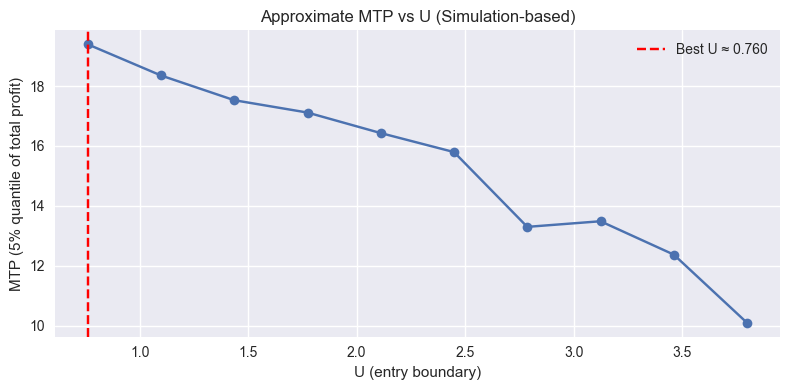

In [17]:
# ============================
# 13. 최소 총 이익(MTP) 기반 최적 경계 탐색 (간단 시뮬 버전)
# ============================

# AR(1) 적합 + 시뮬레이션으로
# “U가 바뀔 때 거래 횟수 & 최소이익” 대략적으로 보는 버전

spread_for_mtp = spread_coint.dropna()

# AR(1) 추정
y_mtp = spread_for_mtp[1:].values
x_mtp = spread_for_mtp.shift(1).dropna().values
phi_hat = np.sum(x_mtp * y_mtp) / np.sum(x_mtp**2)
resid_mtp = y_mtp - phi_hat * x_mtp
sigma_eps = resid_mtp.std()
print("\nAR(1) phi_hat:", phi_hat, ", sigma_eps:", sigma_eps)

T_horizon = 252  # 1년 기준
U_grid = np.linspace(0.5 * sigma_eps, 2.5 * sigma_eps, 10)

mtp_results = []

for U in U_grid:
    n_sims = 500
    profits = []

    for sim in range(n_sims):
        # AR(1) 시뮬레이션
        eps = np.zeros(T_horizon)
        for t in range(1, T_horizon):
            eps[t] = phi_hat * eps[t-1] + np.random.normal(0, sigma_eps)

        # boundary crossing 기반 U-trade만 간단히 계산
        pos = 0
        cum_profit = 0.0
        for t in range(1, T_horizon):
            if pos == 0:
                # open
                if eps[t] >= U:
                    pos = -1  # open U-trade
                    open_level = eps[t]
            else:
                # close when cross 0
                if eps[t] <= 0:
                    profit_trade = open_level - eps[t]
                    cum_profit += profit_trade
                    pos = 0

        profits.append(cum_profit)

    mtp = np.percentile(profits, 5)  # 하위 5%를 "최소 총 이익" 근사
    mtp_results.append((U, mtp))

mtp_df = pd.DataFrame(mtp_results, columns=["U", "MTP_5pct"])
print("\nMTP 결과 (간단 시뮬레이션 기준):")
print(mtp_df)

best_row = mtp_df.iloc[mtp_df["MTP_5pct"].idxmax()]
print("\n근사 최적 U (MTP 최대):", best_row["U"], ", MTP_5pct:", best_row["MTP_5pct"])

plt.figure(figsize=(8,4))
plt.plot(mtp_df["U"], mtp_df["MTP_5pct"], marker="o")
plt.axvline(best_row["U"], color="red", linestyle="--", label=f"Best U ≈ {best_row['U']:.3f}")
plt.title("Approximate MTP vs U (Simulation-based)")
plt.xlabel("U (entry boundary)")
plt.ylabel("MTP (5% quantile of total profit)")
plt.legend()
plt.tight_layout()
plt.show()

AR(1) 기반 스프레드 모델에서, 최소 총 이익(MTP)을 최대화하는 진입 경계는 약 U=0.735로 나타났으며, 이는 스프레드가 해당 수준 이상 벌어졌을 때 진입하는 것이 가장 안정적인 수익 구조를 만든다는 것을 의미

Optimal U from MTP: 0.7599139957985693
sigma(spread_coint): 3.6670895377942263
=> implied optimal k: 0.20722537259225518


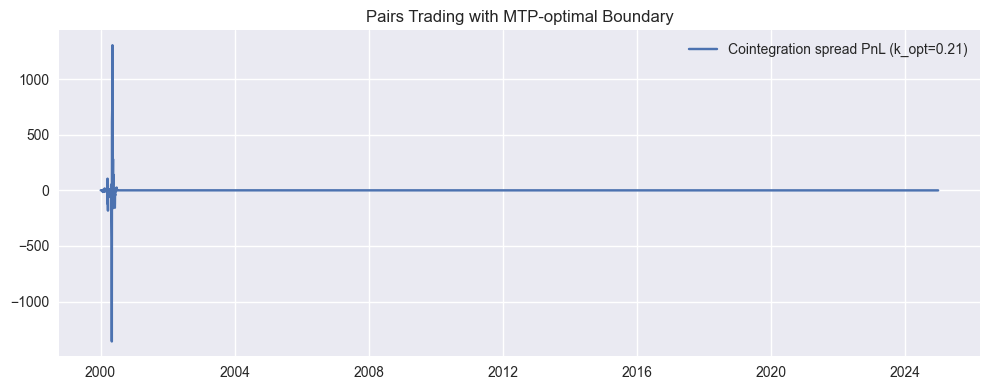


=== Cointegration spread (k_opt=0.21) Performance (Full) ===
Annualized Return  : -1.0
Annualized Vol     : 23.134499676187982
Sharpe Ratio       : -0.04322548635142026
Max Drawdown       : -13.89636039463536
Hurst Exponent     : 0.1788934381873446
Half-life (days)   : 7.356820234749396


{'Strategy': 'Cointegration spread (k_opt=0.21)',
 'AnnReturn': np.float64(-1.0),
 'AnnVol': np.float64(23.134499676187982),
 'Sharpe': np.float64(-0.04322548635142026),
 'MaxDD': np.float64(-13.89636039463536),
 'Hurst': np.float64(0.1788934381873446),
 'HalfLife': np.float64(7.356820234749396)}

In [18]:
# ============================
# MTP로 구한 최적 U를 이용한 백테스트
# ============================

# 1) 시뮬레이션에서 구한 최적 U 가져오기
U_opt = float(best_row["U"])   # 예: 0.735...

# 2) 공적분 스프레드의 표준편차로 나눠서 최적 k 계산
sigma_c = spread_coint.std()
k_opt = U_opt / sigma_c
print("Optimal U from MTP:", U_opt)
print("sigma(spread_coint):", sigma_c)
print("=> implied optimal k:", k_opt)

# 3) 이 k_opt를 이용해 다시 경계 설정
mu_c = spread_coint.mean()
upper_opt = mu_c + k_opt * sigma_c
lower_opt = mu_c - k_opt * sigma_c

# 4) 최적 경계 기반 포지션 생성 (기존 cointegration 전략 룰 재사용)
position_opt = pd.Series(0, index=spread_coint.index)

for t in range(1, len(spread_coint)):
    prev_pos = position_opt.iloc[t-1]
    s = spread_coint.iloc[t]

    if prev_pos == 0:
        if s > upper_opt:
            position_opt.iloc[t] = -1   # 스프레드 너무 큼 → short spread
        elif s < lower_opt:
            position_opt.iloc[t] = 1    # 스프레드 너무 작음 → long spread
        else:
            position_opt.iloc[t] = 0
    else:
        # 평균으로 돌아오면 청산
        if (prev_pos == 1 and s >= mu_c) or (prev_pos == -1 and s <= mu_c):
            position_opt.iloc[t] = 0
        else:
            position_opt.iloc[t] = prev_pos

# 5) 실제 과거 데이터로 PnL 계산 (백테스트)
spread_c_ret = spread_coint.diff().fillna(0)
pnl_opt = -position_opt.shift(1).fillna(0) * spread_c_ret
cum_pnl_opt = (1 + pnl_opt).cumprod()

plt.figure(figsize=(10,4))
plt.plot(cum_pnl_opt, label=f"Cointegration spread PnL (k_opt={k_opt:.2f})")
plt.title("Pairs Trading with MTP-optimal Boundary")
plt.legend()
plt.tight_layout()
plt.show()

# 6) 성과 요약 
perf_opt = summarize_pnl_full(pnl_opt, spread_coint, f"Cointegration spread (k_opt={k_opt:.2f})")
perf_opt

In [19]:
perf_table = pd.DataFrame([perf_simple, perf_coint, perf_kf, perf_hmm])
print(perf_table)

                     Strategy  AnnReturn     AnnVol    Sharpe       MaxDD  \
0         Simple spread (k=1)       -1.0  21.234721 -0.047093  -29.283317   
1        Cointegration spread       -1.0  20.651715 -0.048422   -2.342306   
2               Kalman spread       -1.0  14.691687 -0.068066   -2.915315   
3  HMM + Cointegration spread        NaN  17.399222       NaN -450.512787   

      Hurst  HalfLife  
0  0.185009  7.766269  
1  0.178893  7.356820  
2  0.029697  0.591626  
3  0.178893  7.356820  
